In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [17]:
df = pd.read_csv('Mall_Customers.csv')
print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


In [18]:
print(df.info())
print(df.shape, '-размер таблицы')
print(df.describe())
print(df.isna().sum(),'-количество нулей')

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
(200, 5) -размер таблицы
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000 

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=['Income_scaled', 'Spending_scaled'])
print(X_scaled_df.head())

   Income_scaled  Spending_scaled
0      -1.738999        -0.434801
1      -1.738999         1.195704
2      -1.700830        -1.715913
3      -1.700830         1.040418
4      -1.662660        -0.395980


In [20]:
#Масштабирование обязательно так как признаки измеряются в разных единицах, и если один признак измеряется в больших то он перевешивает другой признак. получается так что по второму признаку кластеры могут плыть


In [21]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


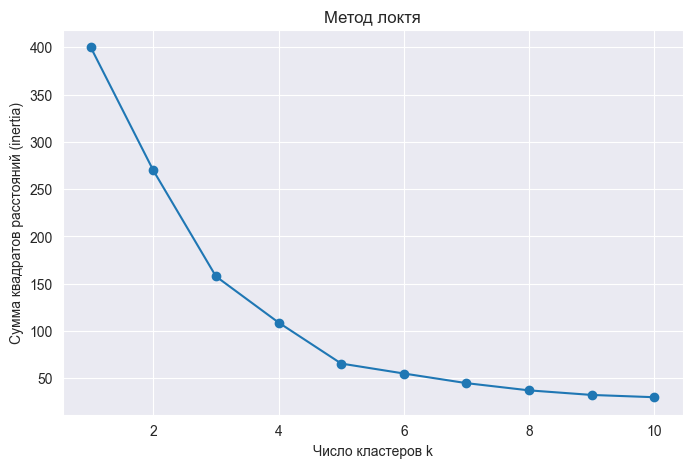

In [22]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Сумма квадратов расстояний (inertia)')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [23]:
#мне кажется что осмысленно выглядят 5 кластеров. так как после 5 график инерции резко замедляется, почему то маркдаун ячейка не показывает текст


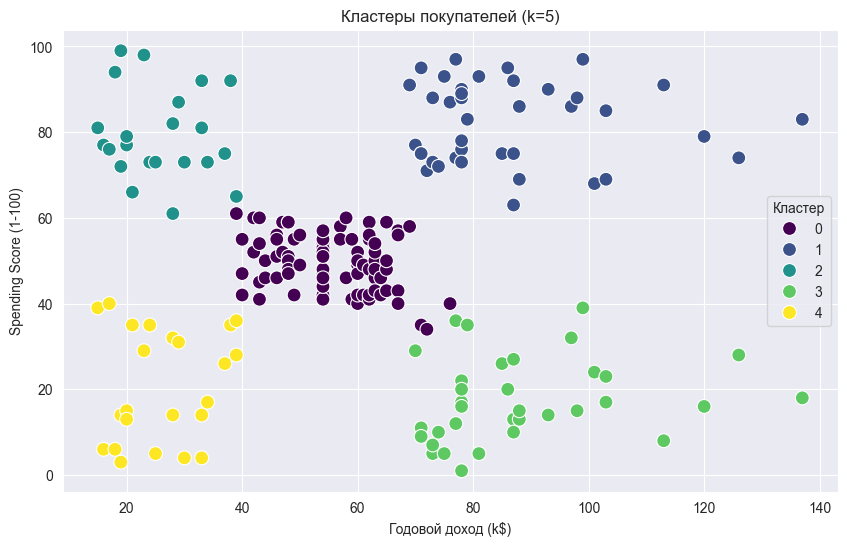

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='viridis', s=100)
plt.title('Кластеры покупателей (k=5)')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Кластер')
plt.show()

In [25]:
cluster_stats = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: x.mode()[0]
}).round(2)

print(cluster_stats)

           Age  Annual Income (k$)  Spending Score (1-100)  Gender
Cluster                                                           
0        42.72               55.30                   49.52  Female
1        32.69               86.54                   82.13  Female
2        25.27               25.73                   79.36  Female
3        41.11               88.20                   17.11    Male
4        45.22               26.30                   20.91  Female


In [26]:
segment_info = {
    'Кластер': [0, 1, 2, 3, 4],
    'Название сегмента': [
        'Средний класс',
        'VIP-активные',
        'Молодые энтузиасты',
        'Богатые консерваторы',
        'Экономные пенсионеры'
    ],
    'Характеристика': [
        'Средний возраст, доход и активность. Ядро базы.',
        'Молодые, высокий доход, максимальные траты. Премиум-клиенты.',
        'Молодые, низкий доход, но высокие траты. Акции и рассрочка.',
        'Высокий доход, но очень низкие траты. Стимулировать эксклюзивом.',
        'Пожилые, низкий доход и траты. Низкий маркетинговый приоритет.'
    ]
}